## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from frank2d import *

## Load data

In [2]:
dir = "../../data/uvtable/"
disk_name = "SimulatedBlob"
data_file = dir +"uvtable_SimulatedBlob.txt"

# Parameters for Geometry class, only for plotting purposes.
inc = 0
pa = 0
dra = 0
ddec = 0

rout = 1

# Load data
file = np.loadtxt(data_file, unpack =True)
u, v, Re, Im, Weights = file
Vis = Re + Im*1j
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

In [21]:
geom = Geometry(inc, pa, dra, ddec)

In [3]:
q = np.hypot(uvtable['u'], uvtable['v'])
q_min = np.min(q)
q_max = np.max(q)

Rmax = 3*rout
import math 
N = math.floor(5* Rmax/rad_to_arcsec * q_max)

print("N =", N)
print("Rmax =", Rmax)

N = 642
Rmax = 3


### The big matrices problem

To surpass the big matrix storage that comes with the extension of the 2D version of Frankenstein, we solve a system of linear equations iteratively rather than performing a direct, computationally prohibitive matrix inversion. 

Substituting the definitions of $\Sigma_{00}$ and $\Sigma_{10}$ into the maximized likelihood expressions allows us to avoid explicit inversion. By defining the auxiliary vector $\widehat{V}$, we arrive at the definitive linear system we aim to solve:

$$\widehat{V} \equiv (I + \mathbf{N}^{-1}S_{11})^{-1}\mathbf{N}^{-1}V_{1}$$

Instead of computing the inverse of the massive matrix $(I + \mathbf{N}^{-1}S_{11})$ directly, we reframe this as a linear system of the form $\mathbf{A}\vec{x} = \vec{b}$:

$$(I + \mathbf{N}^{-1}S_{11}) \widehat{V} = \mathbf{N}^{-1}V_{1}$$

Where the components of this system are defined as follows:
* $\widehat{V}$: Our unknown solution vector $\vec{x}$.
* $V_1$: The actual observed visibilities ($V_{observed}$).
* $\mathbf{N}$: The noise covariance matrix associated with the observed data. Assuming independent Gaussian noise, this is a diagonal matrix of the inverse visibility weights, $\mathbf{N} = \text{diag}(w^{-1})$.
* $S_{11}$: The block of the full prior covariance matrix $S$ that correlates the $(u, v)$ points within the subset of observed data.
* $I$: The identity matrix.

Here, the system matrix is defined as $\mathbf{A} = \mathbf{I} + \mathbf{N}^{-1}S_{11}$ and the target vector as $\vec{b} = \mathbf{N}^{-1}V_{1}$. Crucially, all these components reside in the Fourier domain, allowing us to exploit the sparsity of the kernel matrices discussed in the previous section.

Once the iterative solver finds the optimal vector $\widehat{V}$, we can easily retrieve the complete model solution for both the observed data points ($V_1^{model}$) and the unobserved points ($V_0^{model}$):

$$\begin{aligned}
    V_{1}^{model} &= S_{11} \widehat{V}\\
    V_{0}^{model} &= S_{10}^T\widehat{V}
\end{aligned}$$

This final set of equations defines the core of the algorithm, providing the sought-after complete solution $V^{model}$.

To efficiently solve this system without ever needing to store the full, dense matrix $\mathbf{A}$, we rely on Krylov subspace iterative methods. Since the product of the diagonal noise matrix $\mathbf{N}^{-1}$ and the symmetric covariance matrix $S_{11}$ does not guarantee a strictly symmetric matrix, the **BiConjugate Gradient Stabilized method (BiCGSTAB)** is the optimal algorithm for this problem.

### Iterative Solver Parameters

To control how the `fit` method resolves this linear system under the hood, the function exposes several dedicated parameters:

* **`method_name` (str):** Specifies the iterative algorithm to use. For this non-symmetric system, `'bicgstab'` is the standard and recommended choice. Other options like `'cg'` (Conjugate Gradient) are available but generally require symmetric positive-definite matrices.
* **`method_func` (function):** Allows you to pass a custom iterative solver function. If provided, this takes priority and overrides whatever string is passed to `method_name`.
* **`precond_type` (str):** Specifies the preconditioner to accelerate the convergence of the iterative solver. The default is `'jacobi'`, which uses the diagonal elements of the system matrix $\mathbf{A}$ to approximate its inverse. Preconditioning is highly recommended as it reduces the condition number of the system, allowing BiCGSTAB to find the solution $\widehat{V}$ in significantly fewer iterations.
* **`x0` (array):** The initial guess for the iterative solver. Providing a good starting point for the vector $\widehat{V}$ can drastically reduce the number of iterations required to reach convergence. If `None` is provided, the solver typically starts with a zero vector.
* **`maxiter` (int):** The absolute maximum number of iterations the solver is allowed to perform. The iteration will stop after `maxiter` steps even if the specified tolerance has not been achieved, acting as a safeguard against infinite loops.
* **`rtol` (float):** The relative tolerance for convergence. The solver evaluates the residual error at each step and will successfully terminate once the error falls below this threshold.

In [4]:
frank2d = Frank2D(N, Rmax, verbose = True)

In [5]:
best_Nopt_50 = {'m': np.float64(-1.11786744524583),
 'c': np.float64(2114.0760515814472),
 'l': np.float64(56439.32547348452)}

`set_fit_method` is the wrapper function for defining the iterative solver method and its parameters. The class involver is IterativeSolverMethod.

In [6]:
help(frank2d.set_fit_method)

Help on method set_fit_method in module frank2d.cpu.frank2d:

set_fit_method(method_name='bicgstab', method_func=None, maxiter=50000, rtol=1e-08, precond_type='jacobi', verbose=False) method of frank2d.cpu.frank2d.Frank2D instance
    Setter of the fitting method for the iterative solver.
    Parameters:
    -----------
    method_name : str
        Iterative solver method to use ('cg', 'bicgstab', etc.).
    method_func : function
        Custom iterative solver function. If None, default  is use the method name.
        This is the priority over method_name.
    maxiter : int
        Maximum number of iterations. Iteration will stop after
        maxiter steps even if the specified tolerance has not been achieved.
    rtol : float
        Relative tolerance for the iterative solver.
    precond_type : str
        Type of preconditioner to use.
        Avalaible options are 'jacobi' and 'ilu'.
        - jacobi: Jacobi preconditioner, which uses the inverse of the diagonal of the matri

In [7]:
frank2d.set_fit_method(  method_name = 'bicgstab',
                         method_func = None,
                         maxiter = 50000, rtol = 1e-8,
                         precond_type = 'jacobi',
                         verbose = False
)

[ERROR] Set kernel before setting fit method.


ValueError: Set kernel before setting fit method.

The error shown above was intentionally included for pedagogical purposes. It occurs because if we want to manually intervene in the fitting process, we must strictly follow the sequential order of the pipeline:

* **Gridding:** Process and grid the visibilities -> `frank2d.process_vis()`
* **Initial Guess:** Set the starting point ($\vec{x}_0$) for the final solution vector -> `frank2d.set_x0()`
* **Kernel Setup:** Define the kernel type and parameters (if you have already determined them) -> `frank2d.set_kernel()`
* **Solver Setup:** Choose the iterative method to solve the $\mathbf{A}\vec{x} = \vec{b}$ system -> `frank2d.set_fit_method()`
* **Fitting:** Finally, execute the fit -> `frank2d.fit()`

In [8]:
from frank2d.cpu import IterativeSolverMethod
help(IterativeSolverMethod)

Help on class IterativeSolverMethod in module frank2d.cpu.fitting:

class IterativeSolverMethod(builtins.object)
 |  IterativeSolverMethod(u, v, vis, weights, kernel, method_name='bicgstab', method_func=None, rtol=1e-08, x0=None, maxiter=None, precond_type='jacobi', verbose=False)
 |
 |  Methods defined here:
 |
 |  __init__(self, u, v, vis, weights, kernel, method_name='bicgstab', method_func=None, rtol=1e-08, x0=None, maxiter=None, precond_type='jacobi', verbose=False)
 |       Class to handle the iterative solver methods.
 |
 |      Parameters
 |      ----------
 |      u : 1D array, unit = lambda
 |          The u coordinates of the visibilities.
 |      v : 1D array, unit = lambda
 |          The v coordinates of the visibilities.
 |      vis : 1D array, unit = Jy
 |          The visibilities.
 |      weights : 1D array, unit = 1/Jy^2
 |          The weights of the visibilities.
 |      kernel_row : function
 |          Function that returns the kernel row for a given index.
 |   

In [9]:
frank2d.process_vis(data = uvtable)

===>  Setting gridded data...


When providing an initial guess, you must be careful to evaluate it on the exact same grid that `frank2d` uses internally. These grid coordinates can be accessed directly from the object:

* `X, Y = frank2d.xy_points`: From this, you can construct the $(x, y)$ coordinate tuples where the model is evaluated in the real plane (image domain).
* `U, V = frank2d.uv_points`: From this, you can construct the $(u, v)$ coordinate tuples where the model is evaluated in Fourier space (visibility domain).

In [10]:
frank2d.set_x0(None)

In [11]:
frank2d.set_kernel('wend', kernel_params= best_Nopt_50)

===>  Setting GP Kernel wend...
         + Kernel parameters: {'m': np.float64(-1.11786744524583), 'c': np.float64(2114.0760515814472), 'l': np.float64(56439.32547348452)}


In [12]:
frank2d.set_fit_method(  method_name = 'bicgstab',
                         method_func = None,
                         maxiter = 50000, rtol = 1e-8,
                         precond_type = 'jacobi',
                         verbose = False
)

In [13]:
frank2d.fit()

To plot the information related with the fitting itself with the solver of Ax =b, we can just get the property of the solver of the class Frank2D.

In [16]:
frank2d.solver.info

{'preconditioner_method': 'jacobi',
 'maxiter': 50000,
 'rtol': 1e-08,
 'final_tol': 7.435963551417658,
 'convergence_by': 'norm of r',
 'iterations': 217,
 'solver_method': 'bicgstab',
 'solver_time_sec': 82.67677664756775,
 'CGM_converged': True,
 'Fit_correctly': ' ✘✘✘✘✘✘ Failed..'}

As you can notice here, the fit correctly status is marked as **Failed**. This occurs because the residual error of our iterative solution vector $\vec{x}$ exceeds the demanded tolerance, meaning that $||\mathbf{A}\vec{x} - \vec{b}|| > r_{\text{tol}}$. 

To address this and ensure a successful fit, we can adopt a more conservative approach by either relaxing our criteria (i.e., providing a **larger** `rtol`), or by increasing the maximum number of allowed iterations (`maxiter`) to give the solver more time to converge.

In [17]:
frank2d.set_fit_method(  method_name = 'bicgstab',
                         method_func = None,
                         maxiter = 50000, rtol = 1e-10,
                         precond_type = 'jacobi',
                         verbose = False
)

In [18]:
frank2d.fit()

In [20]:
frank2d.solver.info

{'preconditioner_method': 'jacobi',
 'maxiter': 50000,
 'rtol': 1e-10,
 'final_tol': 0.07435963551417658,
 'convergence_by': 'norm of s',
 'iterations': 296,
 'solver_method': 'bicgstab',
 'solver_time_sec': 111.53862357139587,
 'CGM_converged': True,
 'Fit_correctly': ' ✔✔✔✔✔✔✔ Sucess..'}

In [22]:
Plotter = Plot(frank2d, geom)

You can monitor the residual error (or tolerance) throughout the fitting process using this plot. In some cases, you might observe that the convergence curve "wiggles" or oscillates erratically before finally reaching a solution or having crossed the solution getting far away from it before reaching it again, which can be time expensive.

When this occurs, it is highly recommended to switch the `precond_type` parameter to `'ilu'` (Incomplete LU factorization). This erratic behavior typically happens because the system matrix $\mathbf{A}$ is ill-conditioned. The default `'jacobi'` preconditioner only uses the diagonal elements of the matrix, which might not be sufficient to smooth out the error at each step for highly correlated data. 

The `'ilu'` preconditioner, on the other hand, provides a much stronger approximation of the matrix's inverse by incorporating off-diagonal elements. This effectively clusters the eigenvalues of the system, resulting in a much smoother, more stable, and often faster convergence curve without those unnecessary wiggles.

This is the case for Elias27, we needed to use ilu to find faster convergence, but for AS209 and the mock disc was more than enough using the jacobi preconditioner.

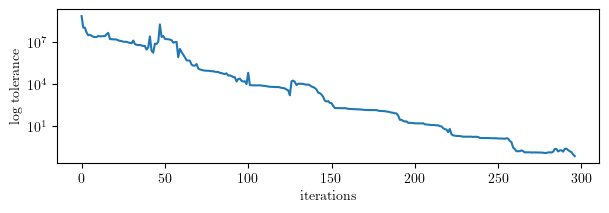

In [23]:
Plotter.cg_tolerance()